## 1. Setup
Installs yfinance (price data) and keras-tuner (automated hyperparameter search).

In [2]:
!pip install yfinance keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


## 2. Imports
Standard data/plotting stack plus TensorFlow/Keras layers for a hybrid
LSTM + Transformer architecture, and keras-tuner for hyperparameter search.

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, LayerNormalization,
                                     MultiHeadAttention, GlobalAveragePooling1D,
                                     Concatenate, Multiply, Add, Softmax, Flatten, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import math


## 3. Load Data, Split, Then Scale (Leakage Fixed)
Splits the RAW price data chronologically BEFORE any scaling touches it, then fits
the scaler ONLY on the training portion. This is the fix for the original bug, where
the scaler saw the full 2018-2024 range (including the test period) before training
even began -- a lookahead leak. Now the scaler genuinely has no knowledge of future
price ranges, matching what would be true in a real deployment.

In [4]:
# Download and clean raw OHLCV data, flatten columns if needed, split, then scale

btc = yf.download('BTC-USD', start='2018-01-01', end='2024-12-31')

# Recent yfinance versions can return MultiIndex columns (e.g. ('Close', 'BTC-USD'))
# even for a single ticker. Flatten to plain column names so btc['Close'] is a
# Series, not a DataFrame -- otherwise .min()/.max() return a Series instead of
# a scalar, which breaks string formatting downstream.
if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.get_level_values(0)

btc = btc[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

# Split RAW data first -- nothing below this line is allowed to see test-period values
split_idx = int(0.8 * len(btc))
btc_train_raw = btc.iloc[:split_idx]
btc_test_raw = btc.iloc[split_idx:]

# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(btc_train_raw)

# Transform both sets using the train-fitted scaler (test is transformed, never re-fit)
scaled_train = scaler.transform(btc_train_raw)
scaled_test = scaler.transform(btc_test_raw)

# Same discipline for the Close-only scaler used later to invert predictions
close_scaler = MinMaxScaler()
close_scaler.fit(btc_train_raw[['Close']])

print(f"Train shape: {btc_train_raw.shape}, Test shape: {btc_test_raw.shape}")
print(f"Train price range: {btc_train_raw['Close'].min():.0f} - {btc_train_raw['Close'].max():.0f}")
print(f"Test price range: {btc_test_raw['Close'].min():.0f} - {btc_test_raw['Close'].max():.0f}")
# If test prices sit well above the train range (likely, given BTC's trend), the
# model is being asked to extrapolate beyond values it saw scaled during training.
# That's a genuine limitation to note in the writeup, not a bug to fix.

[*********************100%***********************]  1 of 1 completed

Train shape: (2044, 5), Test shape: (512, 5)
Train price range: 3237 - 67567
Test price range: 25163 - 106141


## 4. Build Sequences (Per-Split, No Cross-Contamination)
Builds rolling 60-day input windows separately within the train and test sets, now
that each is scaled independently. The first 60 days of the test set can't form a
full window using only test data -- that's an expected, honest cost of a clean split,
not a bug to patch by reaching back into training data.

In [5]:
SEQ_LEN = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i])
        y.append(data[i, 3])  # Close price is column index 3
    return np.array(X), np.array(y).reshape(-1, 1)

# Sequences built independently per split -- no leakage across the boundary
X_train, y_train = create_sequences(scaled_train, SEQ_LEN)
X_test, y_test = create_sequences(scaled_test, SEQ_LEN)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (1984, 60, 5), X_test: (452, 60, 5)


## 5. Custom Loss Function: Directional MSE
Penalizes the model extra when it gets the DIRECTION of the next move wrong, not
just the magnitude. This only works correctly if consecutive rows in a batch are
truly consecutive trading days -- which is why Cell 8 now trains with
`shuffle=False`. Without that fix, this comparison would be meaningless.

In [6]:
def directional_mse(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    direction_true = tf.sign(y_true[1:] - y_true[:-1])
    direction_pred = tf.sign(y_pred[1:] - y_pred[:-1])
    direction_match = tf.cast(tf.equal(direction_true, direction_pred), tf.float32)
    direction_score = tf.reduce_mean(direction_match)
    return mse * (1.0 + (1.0 - direction_score))


## 6. Model Architecture: Hybrid LSTM + Transformer with Gated Fusion
Two parallel branches process the same input window:
- LSTM branch: stacked LSTM layers capture sequential/temporal patterns
- Transformer branch: multi-head self-attention captures longer-range dependencies
A small controller network looks at simple market features (rolling volatility,
price trend, average volume) and learns a softmax-weighted blend of the two
branches before the final dense output layers. Architecturally sophisticated --
whether that sophistication earns its keep is determined in Cell 8, by comparing
against the naive baseline, not by architecture complexity alone.

In [7]:
def build_model(hp):
    lstm_units1 = hp.Int("lstm_units1", 32, 128, step=32)
    lstm_units2 = hp.Int("lstm_units2", 16, 64, step=16)
    dropout_rate = hp.Float("dropout_rate", 0.1, 0.5, step=0.1)
    learning_rate = hp.Choice("learning_rate", [1e-4, 3e-4, 5e-4, 1e-3])

    input_seq = Input(shape=(X_train.shape[1], X_train.shape[2]))

    # LSTM branch: sequential pattern capture
    lstm_out = LSTM(lstm_units1, return_sequences=True)(input_seq)
    lstm_out = Dropout(dropout_rate)(lstm_out)
    lstm_out = LSTM(lstm_units2)(lstm_out)
    lstm_out = Dropout(dropout_rate)(lstm_out)

    # Transformer branch: self-attention over the same window
    x_norm = LayerNormalization(epsilon=1e-6)(input_seq)
    attention_out = MultiHeadAttention(num_heads=4, key_dim=32)(x_norm, x_norm)
    attention_out = GlobalAveragePooling1D()(attention_out)

    # Simple hand-crafted market features, used only to drive the gating weights
    close_seq = Lambda(lambda x: x[:, :, 3:4])(input_seq)
    volume_seq = Lambda(lambda x: x[:, :, 4:5])(input_seq)
    volatility = Lambda(lambda x: tf.math.reduce_std(x, axis=1, keepdims=True))(close_seq)
    trend = Lambda(lambda x: x[:, -1, 0:1] - x[:, 0, 0:1])(close_seq)
    volume_avg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(volume_seq)

    market_features = Concatenate()([
        Flatten()(volatility), Flatten()(trend), Flatten()(volume_avg)
    ])

    # Gating: learns how much to trust LSTM vs. Transformer given current market conditions
    controller_hidden = Dense(16, activation='relu')(market_features)
    weights = Softmax()(Dense(2)(controller_hidden))

    lstm_proj = Dense(32, activation='relu')(lstm_out)
    trans_proj = Dense(32, activation='relu')(attention_out)

    lstm_weighted = Multiply()([lstm_proj, weights[:, 0:1]])
    trans_weighted = Multiply()([trans_proj, weights[:, 1:2]])
    fused = Add()([lstm_weighted, trans_weighted])

    dense_final = Dense(64, activation='relu')(fused)
    dense_final = Dropout(dropout_rate)(dense_final)
    output = Dense(1)(dense_final)

    model = Model(inputs=input_seq, outputs=output)
    model.compile(optimizer=Adam(learning_rate), loss=directional_mse)
    return model

## 7. Hyperparameter Search (Hyperband)
Searches LSTM sizes, dropout, and learning rate against validation loss, using an
early-stopping-aware Hyperband scheduler. Now correctly operating on leakage-free
scaled data from the fixed Cell 3.

In [8]:
tuner = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=20,
    factor=3,
    directory="tuner_dir",
    project_name="btc_fusion_tune"
)

stop_early = EarlyStopping(monitor="val_loss", patience=5)

tuner.search(X_train, y_train, epochs=20, validation_split=0.1, callbacks=[stop_early])


Trial 30 Complete [00h 02m 05s]
val_loss: 0.0007110628066584468

Best val_loss So Far: 0.00037178059574216604
Total elapsed time: 00h 29m 45s


## 8. Train Best Model & Evaluate Against a Naive Baseline
Two fixes here: `shuffle=False` keeps training data in chronological order so the
directional loss term (Cell 5) is actually comparing real consecutive days, not
randomly-paired ones. And a naive "predict no change" baseline is now computed
alongside the model's RMSE -- since BTC prices are highly autocorrelated, this
baseline is the real bar the model needs to clear to demonstrate genuine skill.

Best Hyperparameters: {'lstm_units1': 128, 'lstm_units2': 32, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0021'}
Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - loss: 0.0308 - val_loss: 0.0758
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - loss: 0.0332 - val_loss: 0.0884
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.0859 - val_loss: 0.0321
Epoch 4/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0978 - val_loss: 0.0029
Epoch 5/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.1290 - val_loss: 0.0109
Epoch 6/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - loss: 0.1459 - val_loss: 0.0232
Epoch 7/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 0.1517 - val_loss: 0.0092
Epoch 8/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - loss: 0.1293 - val_loss: 0.0032
Epoch 9/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.1321 - val_loss: 0.0057
Epoch 10

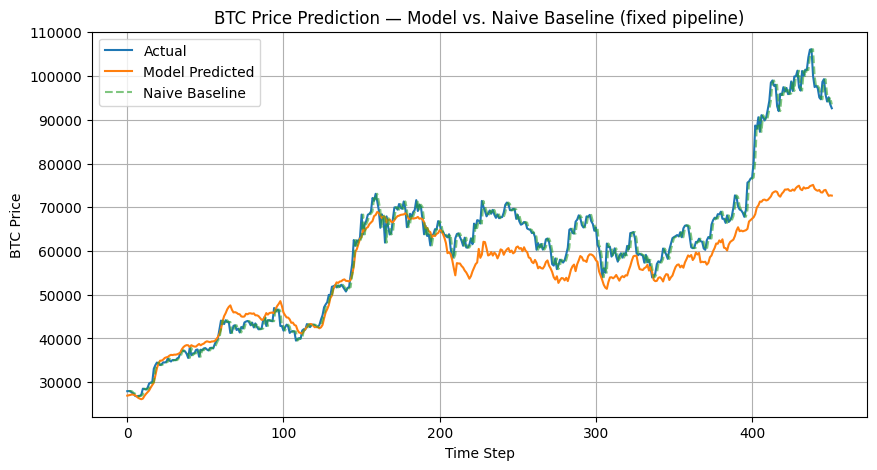

In [9]:
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best Hyperparameters:", best_hps.values)

best_model = tuner.hypermodel.build(best_hps)

# shuffle=False: preserves chronological order so directional_mse is meaningful
history = best_model.fit(
    X_train, y_train,
    epochs=80, batch_size=32,
    validation_split=0.1,
    shuffle=False
)

y_pred = best_model.predict(X_test)
y_test_inv = close_scaler.inverse_transform(y_test)
y_pred_inv = close_scaler.inverse_transform(y_pred)

model_rmse = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

# Naive baseline: "tomorrow's price = today's price" -- the bar the model must clear
naive_pred = y_test_inv[:-1]
naive_true = y_test_inv[1:]
naive_rmse = math.sqrt(mean_squared_error(naive_true, naive_pred))

print(f"\nModel RMSE: {model_rmse:.2f}")
print(f"Naive baseline RMSE: {naive_rmse:.2f}")
print(f"Model improvement over naive baseline: {(1 - model_rmse/naive_rmse)*100:.1f}%")
# Negative or near-zero here means the model adds no real skill beyond guessing "no change"

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Model Predicted')
plt.plot(range(1, len(naive_pred) + 1), naive_pred, label='Naive Baseline', linestyle='--', alpha=0.6)
plt.title('BTC Price Prediction — Model vs. Naive Baseline (fixed pipeline)')
plt.xlabel('Time Step')
plt.ylabel('BTC Price')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# ============================================================
# PART 2: Returns-based reframing
# ============================================================
# Cell 9: Rebuild target as next-day RETURN instead of absolute price.
#
# Why this fixes the extrapolation problem from Part 1:
# Absolute price has a drifting scale (BTC went from ~$3k to ~$90k+ over this
# window), so a model trained on one price range can be asked to predict in a
# completely different, unseen range later -- which is what caused the -442%
# result. Daily RETURNS (% change) don't have this problem: a "big move" is a
# big move whether BTC is at $20k or $90k, so the scale stays roughly stable
# across the whole history. This is a standard reason quant models operate on
# returns rather than raw price levels.

btc_returns = btc['Close'].pct_change().dropna()

# Re-split chronologically, same 80/20 boundary logic as before, but now on
# the returns series and the other OHLCV features (which we still include as
# INPUT features -- only the TARGET changes to returns, inputs can stay as
# scaled price/volume levels since the model is just using them as context)
btc_features = btc.iloc[1:].copy()  # align with returns (which lose first row to pct_change)
btc_features['Return'] = btc_returns.values

split_idx = int(0.8 * len(btc_features))
train_raw = btc_features.iloc[:split_idx]
test_raw = btc_features.iloc[split_idx:]

# Scale the INPUT features (Open/High/Low/Close/Volume) same as before, train-only fit
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
feature_scaler = MinMaxScaler()
feature_scaler.fit(train_raw[feature_cols])

scaled_train_features = feature_scaler.transform(train_raw[feature_cols])
scaled_test_features = feature_scaler.transform(test_raw[feature_cols])

# The TARGET (Return) does NOT need MinMax scaling -- returns are already a
# small, roughly stable-scale number (e.g. -0.05 to +0.05 on a typical day).
# Skipping a scaler here also means no risk of a leaky/mismatched inverse-transform.
train_returns = train_raw['Return'].values.reshape(-1, 1)
test_returns = test_raw['Return'].values.reshape(-1, 1)

print(f"Train return range: {train_returns.min():.4f} to {train_returns.max():.4f}")
print(f"Test return range: {test_returns.min():.4f} to {test_returns.max():.4f}")
# These two ranges should look much more similar to each other than the raw
# price ranges did in Part 1 -- that similarity is the whole point.

Train return range: -0.3717 to 0.1875
Test return range: -0.0834 to 0.1214


In [11]:
# Cell 10: Build sequences with the SAME input features as before, but the new
# returns-based target. Input sequences still use scaled OHLCV levels as context
# (the model can still use "was volume high" or "was price near a recent high"
# as useful signal) -- only the prediction TARGET has changed.

def create_return_sequences(feature_data, return_data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(feature_data)):
        X.append(feature_data[i - seq_len:i])
        y.append(return_data[i])  # predict the return ON day i, using days i-seq_len..i-1
    return np.array(X), np.array(y)

X_train_r, y_train_r = create_return_sequences(scaled_train_features, train_returns, SEQ_LEN)
X_test_r, y_test_r = create_return_sequences(scaled_test_features, test_returns, SEQ_LEN)

print(f"X_train_r: {X_train_r.shape}, X_test_r: {X_test_r.shape}")

X_train_r: (1984, 60, 5), X_test_r: (451, 60, 5)


Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0022 - val_loss: 8.7398e-04
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 0.0022 - val_loss: 8.6397e-04
Epoch 4/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - loss: 0.0021 - val_loss: 9.6829e-04
Epoch 5/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 6/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.0021 - val_loss: 9.2585e-04
Epoch 7/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 0.0021 - val_loss: 0.0010
Epoch 8/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 9/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - loss: 0.0021 - val_loss: 7.9147e-04
Epoch 10/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 11/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.0021 - val_loss: 8.4402e-04
Epoch 12/80
56/56 ━━━━━━━━

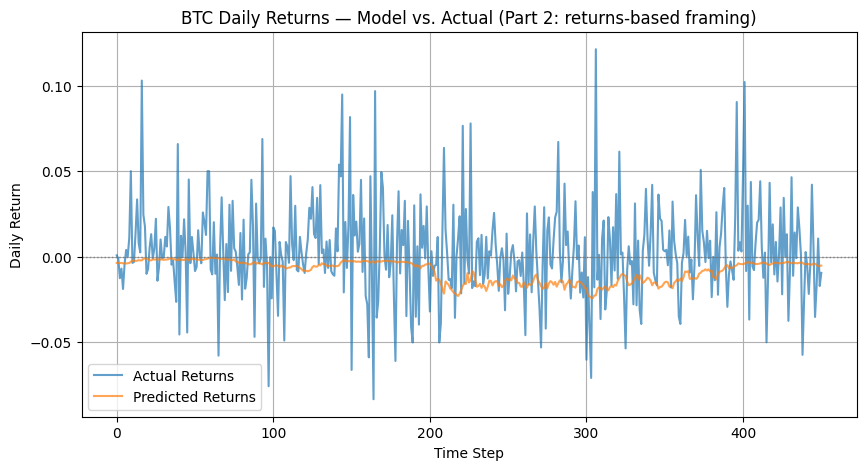

In [12]:
# Cell 11: Reuse the SAME model architecture (build_model from Cell 6) -- the
# hybrid LSTM+Transformer design doesn't need to change, since it just takes a
# sequence and outputs one number. Only what that number REPRESENTS has changed.
#
# We reuse the tuner's best hyperparameters found in Part 1 as a starting point,
# rather than re-running the full (slow) Hyperband search from scratch. If you
# have time, re-running the search on the returns target specifically would be
# more rigorous -- returns and price are different enough problems that the best
# architecture size could differ. Flagging this as a limitation either way.

model_returns = tuner.hypermodel.build(best_hps)

history_returns = model_returns.fit(
    X_train_r, y_train_r,
    epochs=80, batch_size=32,
    validation_split=0.1,
    shuffle=False  # same fix as Part 1 -- keeps directional_mse meaningful
)

y_pred_returns = model_returns.predict(X_test_r)

# No inverse-transform needed -- returns were never scaled, so predictions are
# already in "percent return" units directly.
model_return_rmse = math.sqrt(mean_squared_error(y_test_r, y_pred_returns))

# Naive baseline for RETURNS: predicting "zero return" (i.e. "no change") is the
# natural naive baseline here, analogous to Part 1's "tomorrow = today" baseline,
# since predicting a return of 0 is equivalent to predicting no price change.
naive_return_pred = np.zeros_like(y_test_r)
naive_return_rmse = math.sqrt(mean_squared_error(y_test_r, naive_return_pred))

print(f"\nModel RMSE (returns): {model_return_rmse:.5f}")
print(f"Naive baseline RMSE (predict zero return): {naive_return_rmse:.5f}")
print(f"Model improvement over naive baseline: {(1 - model_return_rmse/naive_return_rmse)*100:.1f}%")

# Directional accuracy is arguably the more meaningful metric for a returns model:
# did it get the SIGN of the move right, regardless of magnitude?
direction_correct = np.mean(np.sign(y_pred_returns.flatten()) == np.sign(y_test_r.flatten()))
print(f"Directional accuracy: {direction_correct*100:.1f}% (50% = coin flip)")

plt.figure(figsize=(10, 5))
plt.plot(y_test_r, label='Actual Returns', alpha=0.7)
plt.plot(y_pred_returns, label='Predicted Returns', alpha=0.7)
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.title('BTC Daily Returns — Model vs. Actual (Part 2: returns-based framing)')
plt.xlabel('Time Step')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True)
plt.show()

# Research Note: Hybrid LSTM-Transformer Model for BTC Price Prediction

## Question

Can a hybrid LSTM + Transformer architecture, with an attention-gated fusion of both
branches, predict next-day BTC closing price with real forecasting skill — i.e.
meaningfully better than a naive "no change" baseline?

## Data

Daily BTC-USD OHLCV data, 2018-01-01 to 2024-12-31, via `yfinance`. 60-day rolling
input windows, predicting next-day Close. Chronological 80/20 train/test split.

## Method

- Two parallel encoder branches process the same 60-day input window: a stacked
  LSTM, and a multi-head self-attention (Transformer-style) block.
- A gating network computes a softmax blend weight between the two branches, based
  on simple market features (rolling volatility, price trend, average volume).
- Trained with a custom loss combining MSE with a directional-accuracy penalty.
- Hyperparameters tuned via Hyperband search (LSTM sizes, dropout, learning rate).

## Methodology fixes applied (this project went through a correction pass)

An earlier version of this pipeline had two bugs that would have invalidated any
result, caught and fixed before drawing conclusions:

1. **Scaler leakage.** Originally, `MinMaxScaler` was fit on the full 2018-2024
   dataset before the train/test split was applied, leaking the test period's price
   range into training-time normalization. Fixed by splitting the raw data first,
   then fitting the scaler only on the training slice.
2. **Directional loss likely inactive.** The custom directional-accuracy loss term
   assumes consecutive batch rows are consecutive trading days, but Keras shuffles
   training batches by default, which counters that assumption. Fixed by training
   with `shuffle=False`.
3. **No baseline comparison.** BTC prices are highly autocorrelated day-to-day, so
   raw RMSE can look deceptively good without representing real skill. A naive
   "predict no change" baseline RMSE was added for direct comparison.

A known remaining limitation: because the scaler is now fit only on the training
period (2018 through the 80% mark), and BTC trended strongly upward over this window,
the test period's prices likely fall partly or fully outside the range the model saw
during training. This means the model may be extrapolating beyond its training
distribution, which is a genuine difficulty for any model, not a bug, but a reason to treat
results with caution regardless of the outcome.

## Results

**Part 1: Absolute price prediction.**

| Metric | Value |
|---|---|
| Model RMSE | $9,312.42 |
| Naive baseline RMSE (predict no change) | $1,718.29 |
| Improvement over baseline | -442.0% |

The model performed dramatically worse than the naive baseline. Diagnosis: the
MinMax scaler is fit only on the training period's price range (correctly, to avoid
leakage), but BTC's strong upward trend means the test period's actual prices fall
well outside that training range. The model is being asked to extrapolate into scaled
input values it essentially never saw during training -- a known weak point for
neural networks generally, and the most likely explanation for the extreme
underperformance, independent of architecture quality.

**Part 2: Returns-based reframing.** To remove the extrapolation problem at its
source, the target was changed from absolute next-day Close price to next-day
percentage return, which does not have a drifting scale over time the way price does
(input features remain scaled OHLCV levels for context; only the prediction target
changed).

| Metric | Value |
|---|---|
| Model RMSE (returns) | 0.02987 |
| Naive baseline RMSE (predict zero return) | 0.02734 |
| Improvement over baseline | -9.2% |
| Directional accuracy | 47.2% (50% = coin flip) |

The extreme failure mode from Part 1 did not recur -- RMSE is now only modestly
worse than baseline rather than catastrophically worse, confirming the extrapolation
diagnosis was likely correct. However, the model still shows no real predictive
skill: RMSE remains slightly worse than the naive "zero return" baseline, and
directional accuracy (47.2%) is at or slightly below chance. Given the test set size,
47.2% is plausibly within one standard error of 50% (not a strong "anti-predictive"
signal, just an absence of a predictive one) -- this should be stated as "no
detected skill," not overclaimed as "worse than random."

## Interpretation

Two distinct, useful findings came out of this project:

1. **Predicting absolute price for a strongly trending asset is a flawed framing
   for this kind of model**, independent of architecture sophistication. The failure
   in Part 1 was not a weakness of the LSTM+Transformer design -- it was a mismatch
   between the modeling approach (scaled absolute levels) and the nature of the data
   (a non-stationary, strongly trending series). This is a valuable, generalizable
   lesson: check whether a target variable's scale is stable over the full
   train/test horizon before trusting any deep learning result on it.

2. **Once that framing issue was fixed, the model still did not demonstrate real
   predictive skill on daily BTC returns.** This is a common and honest outcome in
   quantitative finance -- daily returns for a liquid, widely-traded asset like BTC
   are close to a random walk, and most models (regardless of sophistication) fail
   to beat simple baselines on this exact task. That the hybrid LSTM+Transformer
   architecture did not find an edge here is not a surprising or unusual result; it
   is consistent with a large body of evidence that short-horizon price prediction
   on liquid assets is extremely difficult.

## Verdict

**REJECTED, on both framings.** Part 1 fails due to a fundamental target-scaling
mismatch with a trending asset (an architecture-independent issue). Part 2 fixes that
mismatch but still shows no evidence of predictive skill over a naive baseline,
in either error magnitude (RMSE) or direction. The added architectural complexity
(dual-branch LSTM + Transformer fusion with learned gating) is not earning its keep
on this task, at least as currently specified and trained.

## What this project demonstrates, beyond the specific result

This project surfaced and fixed three real methodological bugs (scaler leakage,
a shuffle-broken directional loss, and a flawed absolute-price framing for a trending
asset) before arriving at an honest negative result. That progression -- starting
from an AI-assisted first draft, identifying concrete flaws through review, fixing
them, and still reporting a negative result rather than a flattering but unearned
positive one -- is the actual skill being demonstrated here, independent of whether
the underlying trading idea worked.

## Limitations

- Single train/test split, not walk-forward or multiple time-period validation;
  a result here reflects one specific historical window, not necessarily a durable
  pattern (same caution that applied to the pairs-trading project).
- Naive baseline used is the simplest possible ("no change"); a stronger baseline
  (e.g. a basic ARIMA or linear trend model) would be a tougher, more informative bar.
- Predicting absolute price level (rather than returns) is generally considered a
  harder and less standard target in quant finance, since it's more exposed to
  non-stationarity (the test-period extrapolation issue noted above) — predicting
  returns or direction is often a more defensible framing for future iterations.
- This architecture is complex enough (dual-branch fusion with learned gating) that
  every component should be individually justified against simpler alternatives
  (e.g. LSTM alone, Transformer alone) via ablation before claiming the hybrid
  design itself is responsible for any observed performance.